# Roll spring added mass comparison

This notebook compares one **spring roll decay test** with two OrcaFlex simulations:

1. **Without added mass correction** (`aeroaddedmass.HydrodynamicInertiaX = 0`)
2. **With added mass correction** (`aeroaddedmass.HydrodynamicInertiaX = 1031`)

Both simulations are run **without viscous damping**, so the difference in the plots is caused by the added inertia correction only.

The plot title shows the estimated period of the experiment and the simulation instead of NRMSE.
The period is calculated from positive peaks only, using the decay part from `t >= 0 s`, with the option to skip the first detected peak and limit the calculation to a maximum time window. This avoids including the release/transient and late low-amplitude/noisy part in the period estimate.


In [138]:
# ============================================================
# 1. Imports
# ============================================================
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import h5py
from scipy.signal import find_peaks

import OrcFxAPI


In [139]:
# ============================================================
# 2. Paths and settings
# ============================================================
data_root = Path(r"C:\Users\verav\Desktop\Studie\Afstuderen\Decay_data\01_Rawdata")
orca_root = Path(r"C:\Users\verav\Desktop\Studie\Afstuderen\PHASE2_ORCA")

exp_path = data_root / "02" / "002" / "34224_03CB_02_002_004_01_Decay1.h5m"
model_path = orca_root / "Harlequin_spring_120s_aerocorrected.dat"

output_dir = Path(r"C:\Users\verav\Desktop\Studie\Afstuderen\Decay_calibration_postprocess")
plots_dir = output_dir / "plots_addedmass_compare_roll_spring"
tables_dir = output_dir / "tables"
plots_dir.mkdir(parents=True, exist_ok=True)
tables_dir.mkdir(parents=True, exist_ok=True)

summary_excel_path = tables_dir / "roll_spring_addedmass_compare.xlsx"

# OrcaFlex object names
vesselname = "floaters"
vesseltypename = "floatertype"
addedmass_object_name = "aeroaddedmass"

# DOF and experiment settings
construction = "spring"
dof = "roll"
prominence = 0.2
min_initial_amp = 3.0

# Added mass cases.
# For roll, the correction is applied to HydrodynamicInertiaX.
# If your model uses a different axis convention, change the field here.
added_mass_cases = {
    "without_added_mass_correction": {
        "plot_title": "Without added mass correction",
        "HydrodynamicMassZ": 0.0,
        "HydrodynamicInertiaX": 0.0,
        "HydrodynamicInertiaY": 0.0,
    },
    "with_added_mass_correction": {
        "plot_title": "With added mass correction",
        "HydrodynamicMassZ": 0.0,
        "HydrodynamicInertiaX": 1000.0,
        "HydrodynamicInertiaY": 0.0,
    },
}

# Plot format: larger title, labels and ticks
TITLE_SIZE = 18
LABEL_SIZE = 16
TICK_SIZE = 14
LEGEND_SIZE = 12
FIGSIZE = (16, 7)
DPI = 200

# Period calculation settings
# Use only the actual decay section and skip the first detected peak, because it can
# be affected by the release/transient at the start of the simulation/experiment.
PERIOD_T_MIN = 0.0
PERIOD_T_MAX = 80.0
PERIOD_SKIP_FIRST_PEAK = True


print("Experiment:", exp_path)
print("Model:", model_path)
print("Plots will be saved to:", plots_dir)


Experiment: C:\Users\verav\Desktop\Studie\Afstuderen\Decay_data\01_Rawdata\02\002\34224_03CB_02_002_004_01_Decay1.h5m
Model: C:\Users\verav\Desktop\Studie\Afstuderen\PHASE2_ORCA\Harlequin_spring_120s_aerocorrected.dat
Plots will be saved to: C:\Users\verav\Desktop\Studie\Afstuderen\Decay_calibration_postprocess\plots_addedmass_compare_roll_spring


In [140]:
# ============================================================
# 3. Experiment helper functions
# ============================================================
def read_decay_signals(exp_path: Path, dof: str):
    filtered_map = {
        "pitch": "CroppedSignals/PITCH (LPF: 5.0 rad*s^-1)",
        "roll": "CroppedSignals/ROLL (LPF: 5.0 rad*s^-1)",
        "heave": "CroppedSignals/Z_COG (LPF: 5.0 rad*s^-1)",
    }

    unfiltered_map = {
        "pitch": "UnfilteredSignals/PITCH (unfiltered)",
        "roll": "UnfilteredSignals/ROLL (unfiltered)",
        "heave": "UnfilteredSignals/Z_COG (unfiltered)",
    }

    with h5py.File(exp_path, "r") as f:
        t_filt = np.array(f["CroppedSignals/time"])
        z_filt = np.array(f[filtered_map[dof]])
        t = np.array(f["UnfilteredSignals/time"])
        z = np.array(f[unfiltered_map[dof]])

    return t_filt, z_filt, t, z


def find_first_zero_crossing(t, z):
    z = np.asarray(z)
    for i in range(1, len(z)):
        if z[i - 1] == 0:
            return i - 1, t[i - 1]
        if z[i - 1] * z[i] < 0:
            return i, t[i]
    raise ValueError("No zero crossing found.")


def find_initial_amplitude_from_zero_crossing(t, z, t_zero, search_window=20.0):
    mask = (t >= t_zero - search_window) & (t <= t_zero)
    if np.sum(mask) == 0:
        raise ValueError("No data found in search window for initial amplitude.")
    t_win = t[mask]
    z_win = z[mask]
    i_local = np.argmax(np.abs(z_win))
    return t_win[i_local], z_win[i_local]


def classify_extremum_type(a_value):
    return "peak" if a_value >= 0 else "trough"


def find_first_two_same_type_extrema_after_reference(t, z, t_reference, extremum_type, prominence):
    t = np.asarray(t)
    z = np.asarray(z)

    if extremum_type == "peak":
        idx_all, _ = find_peaks(z, prominence=prominence)
    elif extremum_type == "trough":
        idx_all, _ = find_peaks(-z, prominence=prominence)
    else:
        raise ValueError(f"Unknown extremum_type: {extremum_type}")

    idx_after_ref = idx_all[t[idx_all] >= t_reference]
    if len(idx_after_ref) < 2:
        raise ValueError(f"Not enough {extremum_type}s found after reference time {t_reference:.3f} s.")

    idx_A1 = int(idx_after_ref[0])
    idx_A2 = int(idx_after_ref[1])

    return {
        "idx_A1": idx_A1,
        "t_A1": float(t[idx_A1]),
        "a_A1": float(z[idx_A1]),
        "idx_A2": idx_A2,
        "t_A2": float(t[idx_A2]),
        "a_A2": float(z[idx_A2]),
        "type": extremum_type,
    }


def prepare_experiment(exp_path: Path, dof: str):
    t_filt, z_filt, t, z = read_decay_signals(exp_path, dof)

    _, t_zero = find_first_zero_crossing(t_filt, z_filt)
    t_release_guess, a_release_guess = find_initial_amplitude_from_zero_crossing(
        t, z, t_zero, search_window=20.0
    )

    if abs(a_release_guess) < min_initial_amp:
        raise ValueError(
            f"Initial amplitude too small for {dof}: {a_release_guess:.4f} "
            f"(minimum {min_initial_amp:.4f})"
        )

    extremum_type = classify_extremum_type(a_release_guess)
    ext_info = find_first_two_same_type_extrema_after_reference(
        t=t,
        z=z,
        t_reference=t_release_guess,
        extremum_type=extremum_type,
        prominence=prominence,
    )

    mask_decay = t >= ext_info["t_A2"]
    t_decay = t[mask_decay] - ext_info["t_A2"]
    z_decay = z[mask_decay]
    t_full_rel = t - ext_info["t_A2"]

    return {
        "exp_path": exp_path,
        "dof": dof,
        "t_filtered": t_filt,
        "z_filtered": z_filt,
        "t_full": t,
        "z_full": z,
        "t_full_rel": t_full_rel,
        "t_zero": t_zero,
        "t_A1": ext_info["t_A1"],
        "a_A1": ext_info["a_A1"],
        "t_A2": ext_info["t_A2"],
        "a_A2": ext_info["a_A2"],
        "extremum_type": extremum_type,
        "t_decay": t_decay,
        "z_decay": z_decay,
    }


In [141]:
# ============================================================
# 4. Extrema, period and NRMSE helper functions
# ============================================================
def get_peaks_and_troughs(t, z, prominence):
    peaks, _ = find_peaks(z, prominence=prominence)
    troughs, _ = find_peaks(-z, prominence=prominence)
    return {
        "peak_idx": peaks,
        "trough_idx": troughs,
        "t_peaks": t[peaks],
        "z_peaks": z[peaks],
        "t_troughs": t[troughs],
        "z_troughs": z[troughs],
    }


def calculate_period(time, signal, prominence=None, t_min=0.0, t_max=None, skip_first_peak=True):
    """
    Calculate the period from positive peaks in the time series.

    The calculation uses only the selected time window. By default it starts at
    t = 0 s, so the release/transient before the decay start is ignored. The
    first detected peak can also be skipped, because it is often influenced by
    the initialisation/release.
    """
    time = np.asarray(time, dtype=float)
    signal = np.asarray(signal, dtype=float)

    mask = np.isfinite(time) & np.isfinite(signal) & (time >= t_min)
    if t_max is not None:
        mask = mask & (time <= t_max)

    time = time[mask]
    signal = signal[mask]

    if len(time) < 3:
        return np.nan

    if prominence is None:
        peaks, _ = find_peaks(signal)
    else:
        peaks, _ = find_peaks(signal, prominence=prominence)

    if skip_first_peak and len(peaks) > 2:
        peaks = peaks[1:]

    if len(peaks) < 2:
        return np.nan

    peak_times = time[peaks]
    periods = np.diff(peak_times)
    periods = periods[np.isfinite(periods)]

    if len(periods) == 0:
        return np.nan

    return float(np.mean(periods))


def estimate_period_from_extrema(extrema):
    """Legacy period estimate from both peaks and troughs. Kept for reference."""
    periods = []
    if len(extrema["t_peaks"]) >= 2:
        periods.extend(np.diff(extrema["t_peaks"]).tolist())
    if len(extrema["t_troughs"]) >= 2:
        periods.extend(np.diff(extrema["t_troughs"]).tolist())

    periods = np.asarray(periods, dtype=float)
    periods = periods[np.isfinite(periods)]
    if len(periods) == 0:
        return np.nan
    return float(np.mean(periods))


def match_extrema_by_order(z_ref, z_sim):
    n = min(len(z_ref), len(z_sim))
    if n == 0:
        return np.array([]), np.array([])
    return np.asarray(z_ref[:n]), np.asarray(z_sim[:n])


def compute_nrmse(z_ref, z_sim):
    z_ref = np.asarray(z_ref)
    z_sim = np.asarray(z_sim)
    if len(z_ref) == 0 or len(z_sim) == 0:
        return np.nan
    scale = np.maximum(np.abs(z_ref), 1e-6)
    return np.sqrt(np.mean(((z_sim - z_ref) / scale) ** 2))


def compute_score_from_extrema(exp_extrema, sim_extrema):
    z_ref_peaks, z_sim_peaks = match_extrema_by_order(exp_extrema["z_peaks"], sim_extrema["z_peaks"])
    z_ref_troughs, z_sim_troughs = match_extrema_by_order(exp_extrema["z_troughs"], sim_extrema["z_troughs"])

    nrmse_peaks = compute_nrmse(z_ref_peaks, z_sim_peaks)
    nrmse_troughs = compute_nrmse(z_ref_troughs, z_sim_troughs)

    vals = [v for v in [nrmse_peaks, nrmse_troughs] if np.isfinite(v)]
    score = np.mean(vals) if len(vals) > 0 else np.inf

    return score, nrmse_peaks, nrmse_troughs, len(z_ref_peaks), len(z_ref_troughs)


In [142]:
# ============================================================
# 5. OrcaFlex helper functions
# ============================================================
def safe_setattr(obj, attr_name: str, value: float):
    """Set an OrcaFlex attribute if it exists. This keeps the notebook robust to model variants."""
    try:
        setattr(obj, attr_name, float(value))
    except Exception:
        pass


def set_initial_roll_amplitude(vessel, amplitude_deg: float):
    """Set only roll/heel initial amplitude; all other initial offsets are zero."""
    vessel.InitialX = 0.0
    vessel.InitialY = 0.0
    vessel.InitialZ = 0.0
    vessel.InitialHeel = float(amplitude_deg)
    vessel.InitialTrim = 0.0
    vessel.InitialHeading = 0.0


def set_all_viscous_damping_to_zero(vesseltype):
    """Disable viscous other damping for all relevant DOFs."""
    damping_attributes = [
        "OtherDampingLinearCoeffx", "OtherDampingQuadraticCoeffx",
        "OtherDampingLinearCoeffy", "OtherDampingQuadraticCoeffy",
        "OtherDampingLinearCoeffz", "OtherDampingQuadraticCoeffz",
        "OtherDampingLinearCoeffRx", "OtherDampingQuadraticCoeffRx",
        "OtherDampingLinearCoeffRy", "OtherDampingQuadraticCoeffRy",
        "OtherDampingLinearCoeffRz", "OtherDampingQuadraticCoeffRz",
    ]
    for attr in damping_attributes:
        safe_setattr(vesseltype, attr, 0.0)


def set_aero_added_mass(model, values: dict):
    """Set hydrodynamic added mass/inertia on the OrcaFlex object 'aeroaddedmass'."""
    aeroaddedmass = model[addedmass_object_name]
    aeroaddedmass.HydrodynamicMassZ = float(values["HydrodynamicMassZ"])
    aeroaddedmass.HydrodynamicInertiaX = float(values["HydrodynamicInertiaX"])
    aeroaddedmass.HydrodynamicInertiaY = float(values["HydrodynamicInertiaY"])


def run_roll_decay_without_viscous_damping(model_path: Path, initial_roll_deg: float, added_mass_values: dict):
    """Run one roll decay simulation without viscous damping and with the requested added mass settings."""
    model = OrcFxAPI.Model(str(model_path))
    vessel = model[vesselname]
    vesseltype = model[vesseltypename]

    set_aero_added_mass(model, added_mass_values)
    set_all_viscous_damping_to_zero(vesseltype)
    set_initial_roll_amplitude(vessel, initial_roll_deg)

    model.RunSimulation()

    t = np.asarray(model.general.TimeHistory("Time"), dtype=float)
    z = np.asarray(vessel.TimeHistory("Rotation 1"), dtype=float)  # roll/heel [deg]
    return t, z


In [143]:
# ============================================================
# 6. Run the two simulations
# ============================================================
exp_info = prepare_experiment(exp_path, dof)
exp_extrema = get_peaks_and_troughs(exp_info["t_decay"], exp_info["z_decay"], prominence=prominence)
exp_period = calculate_period(
    exp_info["t_decay"],
    exp_info["z_decay"],
    prominence=prominence,
    t_min=PERIOD_T_MIN,
    t_max=PERIOD_T_MAX,
    skip_first_peak=PERIOD_SKIP_FIRST_PEAK,
)

results = []

for case_id, case in added_mass_cases.items():
    print("Running:", case["plot_title"])

    t_sim_raw, z_sim_raw = run_roll_decay_without_viscous_damping(
        model_path=model_path,
        initial_roll_deg=exp_info["a_A2"],
        added_mass_values=case,
    )

    t_sim = t_sim_raw - t_sim_raw[0]
    z_sim = z_sim_raw.copy()
    sim_extrema = get_peaks_and_troughs(t_sim, z_sim, prominence=prominence)
    sim_period = calculate_period(
        t_sim,
        z_sim,
        prominence=prominence,
        t_min=PERIOD_T_MIN,
        t_max=PERIOD_T_MAX,
        skip_first_peak=PERIOD_SKIP_FIRST_PEAK,
    )

    nrmse_total, nrmse_peaks, nrmse_troughs, n_peaks, n_troughs = compute_score_from_extrema(
        exp_extrema,
        sim_extrema,
    )

    results.append({
        "case_id": case_id,
        "plot_title": case["plot_title"],
        "HydrodynamicMassZ": case["HydrodynamicMassZ"],
        "HydrodynamicInertiaX": case["HydrodynamicInertiaX"],
        "HydrodynamicInertiaY": case["HydrodynamicInertiaY"],
        "experiment_period_s": exp_period,
        "simulation_period_s": sim_period,
        "period_t_min_s": PERIOD_T_MIN,
        "period_t_max_s": PERIOD_T_MAX,
        "period_skip_first_peak": PERIOD_SKIP_FIRST_PEAK,
        "nrmse_total": nrmse_total,
        "nrmse_peaks": nrmse_peaks,
        "nrmse_troughs": nrmse_troughs,
        "n_matched_peaks": n_peaks,
        "n_matched_troughs": n_troughs,
        "t_sim": t_sim,
        "z_sim": z_sim,
        "sim_init_amp": float(z_sim[0]) if len(z_sim) else np.nan,
    })

summary_df = pd.DataFrame([
    {k: v for k, v in r.items() if k not in ["t_sim", "z_sim"]}
    for r in results
])

display(summary_df)


Running: Without added mass correction
Running: With added mass correction


,case_id,plot_title,HydrodynamicMassZ,HydrodynamicInertiaX,HydrodynamicInertiaY,experiment_period_s,simulation_period_s,period_t_min_s,period_t_max_s,period_skip_first_peak,nrmse_total,nrmse_peaks,nrmse_troughs,n_matched_peaks,n_matched_troughs,sim_init_amp
0,without_added_mass_correction,Without added mass correction,0.0,0.0,0.0,7.186583,7.022222,0.0,80.0,True,2.852899,2.924487,2.781312,20,19,-6.944191
1,with_added_mass_correction,With added mass correction,0.0,1000.0,0.0,7.186583,7.177778,0.0,80.0,True,2.631366,2.576601,2.686130,19,19,-6.944191


In [144]:
# ============================================================
# 7. Plot function in the requested format
# ============================================================
def plot_added_mass_case(result, save_dir: Path):
    exp_name = exp_path.stem
    t_exp = exp_info["t_decay"]
    z_exp = exp_info["z_decay"]
    t_exp_full_rel = exp_info["t_full_rel"]
    z_exp_full = exp_info["z_full"]
    t_sim = result["t_sim"]
    z_sim = result["z_sim"]

    exp_ext = get_peaks_and_troughs(t_exp, z_exp, prominence=prominence)
    sim_ext = get_peaks_and_troughs(t_sim, z_sim, prominence=prominence)

    fig, ax = plt.subplots(figsize=FIGSIZE)

    ax.plot(
        t_exp_full_rel,
        z_exp_full,
        label="Experiment",
        linewidth=2.3,
        color="#1f77b4",
    )
    ax.plot(
        t_sim,
        z_sim,
        label="Simulation without damping",
        linewidth=2.3,
        color="orange",
    )

    ax.scatter(exp_ext["t_peaks"], exp_ext["z_peaks"], s=55, marker="o", color="#1f77b4")
    ax.scatter(
        exp_ext["t_troughs"],
        exp_ext["z_troughs"],
        s=55,
        marker="o",
        label="Extrema (experiment)",
        color="#1f77b4",
    )
    ax.scatter(sim_ext["t_peaks"], sim_ext["z_peaks"], s=55, marker="o", color="orange")
    ax.scatter(
        sim_ext["t_troughs"],
        sim_ext["z_troughs"],
        s=55,
        marker="o",
        label="Extrema (simulation)",
        color="orange",
    )

    ax.scatter(
        [0.0],
        [result["sim_init_amp"]],
        s=220,
        marker="x",
        linewidths=3.5,
        color="orange",
        label="Initial amplitude (simulation)",
    )

    t_A1_rel = exp_info["t_A1"] - exp_info["t_A2"]
    dt = np.median(np.diff(t_exp)) if len(t_exp) > 1 else 0.5
    x_start = t_A1_rel - 2.0 * dt
    x_end = t_sim[-1] if len(t_sim) > 0 else 0.0
    ax.set_xlim(x_start - 10.0, x_end)

    ax.set_title(
        f"Type: spring - DOF: roll - Exp: {exp_name}\n"
        f"{result['plot_title']} | "
        f"Experiment period: {result['experiment_period_s']:.3f} s | "
        f"Simulation period: {result['simulation_period_s']:.3f} s\n",
        fontsize=TITLE_SIZE,
    )
    ax.set_xlabel("Time [s]", fontsize=LABEL_SIZE)
    ax.set_ylabel("Roll [degrees]", fontsize=LABEL_SIZE)
    ax.tick_params(axis="both", labelsize=TICK_SIZE)
    ax.grid(True)
    ax.legend(fontsize=LEGEND_SIZE)
    fig.tight_layout()

    save_dir.mkdir(parents=True, exist_ok=True)
    out_path = save_dir / f"roll_spring_{exp_name}_{result['case_id']}.png"
    fig.savefig(out_path, dpi=DPI)
    plt.show()
    plt.close(fig)

    return out_path


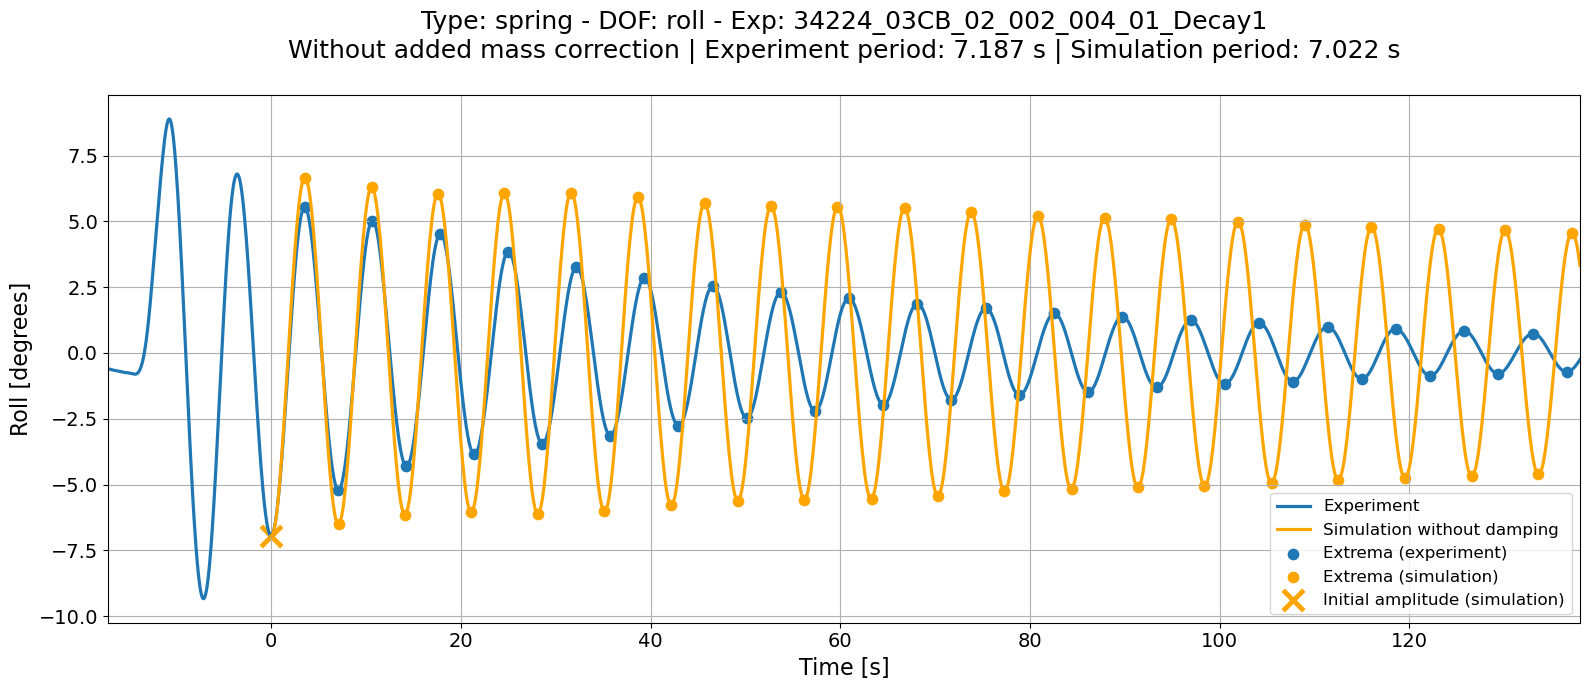

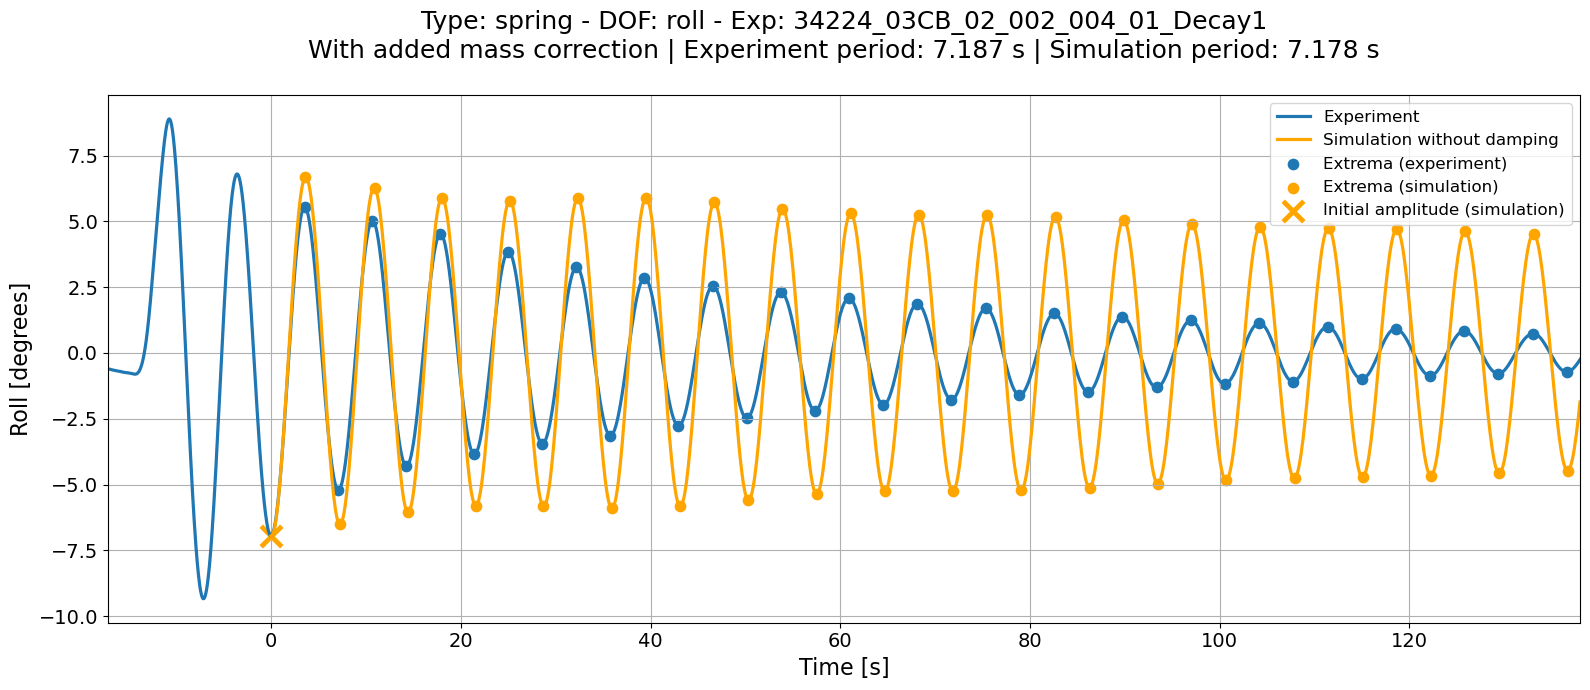

Saved plots:
C:\Users\verav\Desktop\Studie\Afstuderen\Decay_calibration_postprocess\plots_addedmass_compare_roll_spring\roll_spring_34224_03CB_02_002_004_01_Decay1_without_added_mass_correction.png
C:\Users\verav\Desktop\Studie\Afstuderen\Decay_calibration_postprocess\plots_addedmass_compare_roll_spring\roll_spring_34224_03CB_02_002_004_01_Decay1_with_added_mass_correction.png
Saved summary: C:\Users\verav\Desktop\Studie\Afstuderen\Decay_calibration_postprocess\tables\roll_spring_addedmass_compare.xlsx


In [145]:
# ============================================================
# 8. Save the two plots and the summary table
# ============================================================
plot_paths = []
for result in results:
    out_path = plot_added_mass_case(result, plots_dir)
    plot_paths.append(out_path)

summary_df["plot_path"] = [str(p) for p in plot_paths]
summary_df["exp_path"] = str(exp_path)
summary_df["model_path"] = str(model_path)
summary_df["initial_roll_amplitude_A2"] = exp_info["a_A2"]
summary_df.to_excel(summary_excel_path, index=False)

print("Saved plots:")
for p in plot_paths:
    print(p)
print("Saved summary:", summary_excel_path)
